In [1]:
import os
import sys
import torch
import json
import plotly.express as px
print("importing transformerlens utils")
from transformer_lens import utils
print("finished importing transformerlens utils")
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

cwd = os.getcwd()
cwd = cwd.split("notebooks")[0]
print(cwd)
sys.path.append(cwd + "/scripts")
from error_eval import *
from plots import *

importing transformerlens utils
finished importing transformerlens utils
/n/data2/hms/dbmi/sunyaev/lab/dlee/ai_safety/sae_pathology/


# Functions

In [3]:
sae_name = 'gpt2_resid_pre'

directory = os.path.join(cwd + 'results/error_extrapolation', sae_name)

def read_file(model_id, nrows = None):
    data_path = directory + f'/e2e_{model_id}_layer_6_pos_all.csv'
    if nrows:
        result_df = pd.read_csv(data_path, nrows=nrows)
    else:
        result_df = pd.read_csv(data_path)

    return result_df

def get_alive_dict_elements(model_id):
    result_df = read_file(model_id, nrows = 3)

    if type(result_df["alive_dict_elements"][0]) == str:
        return int(result_df["alive_dict_elements"][0].split("(")[1].split(",")[0])
    else:
        return result_df["alive_dict_elements"][0]

def get_mean_df(model_id):
    result_df = read_file(model_id)
    result_df = result_df.drop(['token'], axis=1)
    mean_df = pd.DataFrame(result_df.mean(axis=0)).T
    return mean_df

def get_median_df(model_id):
    result_df = read_file(model_id)
    result_df = result_df.drop(['token', 'alive_dict_elements'], axis=1)
    median_df = pd.DataFrame(result_df.median(axis=0)).T
    return median_df

length_list = list(range(1, 20, 2)) + list(range(20, 50, 4)) + list(range(51, 101, 10))
col_names_normal = [f'length_{length}_kl' for length in length_list]
col_names_l2_normal = [f'length_{length}_blocks.11.hook_resid_post_L2' for length in length_list]

def melt_by_col_names(df, col_names, id_vars = None):
    if id_vars:
        mean_df_melt = pd.melt(df, id_vars=id_vars, value_vars=col_names, ignore_index=False)
    else:
        mean_df_melt = pd.melt(df, value_vars=col_names, ignore_index=False)
    mean_df_melt["perturbation_length"] = mean_df_melt["variable"].str.split("_", expand = True)[1].astype(float)

    return mean_df_melt

# Get model names

In [4]:
from e2e_sae.scripts.analysis.utils import create_run_df, get_df_gpt2
df = get_df_gpt2()

performance_df = df.copy()

#get models that were used in the performance plot of the paper
performance_df = df.loc[(df["ratio"] == 60) & (df["seed"] == 0) & (df["n_samples"] == 400_000)]

# Ignore specialised runs
performance_df = performance_df.loc[
    ~performance_df["name"].str.contains("seed-comparison")
    & ~performance_df["name"].str.contains("lr-comparison")
    & ~performance_df["name"].str.contains("lower-downstream")
    & -performance_df["name"].str.contains("e2e-local")
    & ~performance_df["name"].str.contains("recon-all")
    & ~performance_df["name"].str.contains("misc_")]

columns_list = ["id", "sae_pos", "run_type", "layer", "L0", "CELossIncrease", "alive_dict_elements"]
df_local = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "local")].sort_values("L0")
df_e2e = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "e2e")].sort_values("L0")
df_downstream = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "downstream")].sort_values("L0")

Processing runs: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 299/299 [00:10<00:00, 28.21it/s]


In [5]:
df_all = pd.concat([df_local, df_e2e, df_downstream])
df_interest = df_all.copy().reset_index()

In [25]:
df_e2e["L0"]

251     21.028400
250     27.499313
249     39.681484
248     77.049683
247    146.818863
246    428.470720
Name: L0, dtype: float64

# Add baselines

In [57]:
layer_list = ["cov_random_mixture", "real_direction_mixture"]

mean_df_dict_baseline = {}

for layer in layer_list:
    print(layer)
    filename = f"{layer}_seed_23_layer_6_pos_all.csv"
    result_df = pd.read_csv(cwd + "/results/sensitive_direction/gpt2_resid_pre/" + filename)

    mean_df = pd.DataFrame(result_df.mean(axis=0)).T
    mean_df_dict_baseline[layer] = mean_df

mean_df_list = []
for layer in layer_list:
    mean_df = mean_df_dict_baseline[layer]
    mean_df["baseline"] = layer
    mean_df_list.append(mean_df)

mean_df_all_baseline = pd.concat(mean_df_list)

cov_random_mixture
real_direction_mixture


# Draw Extrapolation Plots

In [32]:
df_interest["mean_df"] = [get_mean_df(x) for x in df_interest["id"]]
mean_df_all = pd.concat(list(df_interest["mean_df"])).reset_index()

In [33]:
mean_df_all["run_type"] = df_interest["run_type"]
mean_df_all["L0"] = df_interest["L0"]

In [34]:
mean_df_all_melt_l2 = melt_by_col_names(mean_df_all, col_names_l2_normal, id_vars = ["run_type", "L0"])
mean_df_all_melt_l2["metric"] = "L2 at Layer 11 resid_post"

mean_df_all_melt_kl = melt_by_col_names(mean_df_all, col_names_normal, id_vars = ["run_type", "L0"])
mean_df_all_melt_kl["metric"] = "KL"

# mean_df_all_melt = pd.concat([mean_df_all_melt_l2, mean_df_all_melt_kl])
mean_df_melt = pd.concat([mean_df_all_melt_l2, mean_df_all_melt_kl])

mean_df_melt["perturbation_length"] = mean_df_melt["variable"].str.split("_", expand = True)[1].astype(int)
# mean_df_melt["perturbation_type"] = mean_df_melt["variable"].str.split("_", expand = True)[0]

mean_df_melt["L0"] = [f"{x:.1f}" for x in mean_df_melt["L0"]]
mean_df_melt["L0"] = mean_df_melt["L0"].astype(float)

In [35]:
mean_df_melt_short = mean_df_melt[mean_df_melt["perturbation_length"] < 50]
mean_df_melt_short["length_type"] = "short"
mean_df_melt["length_type"] = "long"

mean_df_melt_all = pd.concat([mean_df_melt_short, mean_df_melt])

/tmp/ipykernel_15456/1051651054.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df_melt_short["length_type"] = "short"


In [67]:
axes = g.fig.axes
for ax in axes:
    print(ax)

Axes(0.05575,0.537938;0.256202x0.421728)
Axes(0.348927,0.537938;0.256202x0.421728)
Axes(0.642104,0.537938;0.256202x0.421728)
Axes(0.05575,0.0700156;0.256202x0.421728)
Axes(0.348927,0.0700156;0.256202x0.421728)
Axes(0.642104,0.0700156;0.256202x0.421728)


In [69]:
ax[0]

TypeError: 'Axes' object is not subscriptable

In [59]:
mean_df_all_baseline_melt_l2 = melt_by_col_names(mean_df_all_baseline, col_names_l2_normal, id_vars = ["baseline"])
mean_df_all_baseline_melt_l2["metric"] = "L2 at Layer 11 resid_post"

mean_df_all_baseline_melt_kl = melt_by_col_names(mean_df_all_baseline, col_names_normal, id_vars = ["baseline"])
mean_df_all_baseline_melt_kl["metric"] = "KL"

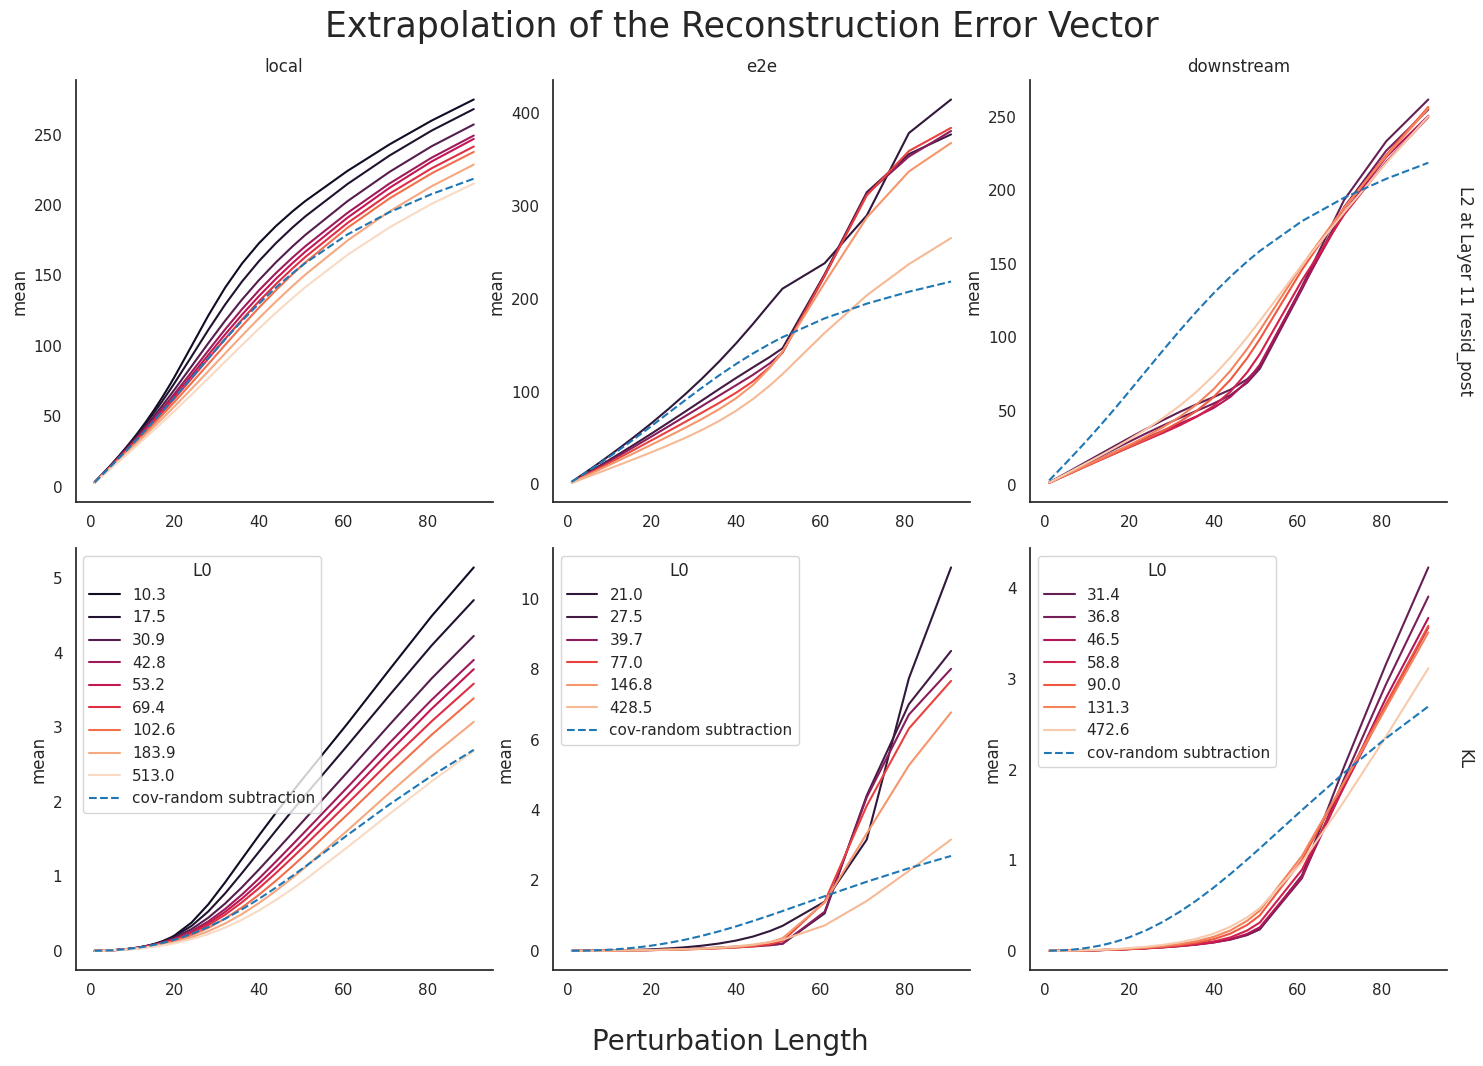

In [85]:
sns.set_theme(style="white")

mean_df_melt_plot = mean_df_melt.copy()
# mean_df_melt_plot = mean_df_melt[(mean_df_melt["L0"] >= 30)]

g = sns.FacetGrid(mean_df_melt_plot, col="run_type", row = "metric", height=5, margin_titles=True, hue = "L0", 
                  palette = 'rocket',  sharex=False, sharey=False)

g.map(sns.lineplot, "perturbation_length", "value")

g.set_titles(col_template="{col_name}", row_template="{row_name}")

g.fig.suptitle(f'Extrapolation of the Reconstruction Error Vector', y = 1.03, fontsize = 25)

g.set(xlabel= None, ylabel = "mean")


g.fig.text(0.4, -0.01, "Perturbation Length", fontsize = 20)

axes = g.fig.axes
i = 0
for ax in axes:
    if i < 3:
        ax.plot(mean_df_all_baseline_melt_l2[mean_df_all_baseline_melt_l2["baseline"] == "cov_random_mixture"]["perturbation_length"],
            mean_df_all_baseline_melt_l2[mean_df_all_baseline_melt_l2["baseline"] == "cov_random_mixture"]["value"],
            c='tab:blue', label = "cov-random subtraction", linestyle='dashed')
    else:
        ax.plot(mean_df_all_baseline_melt_kl[mean_df_all_baseline_melt_kl["baseline"] == "cov_random_mixture"]["perturbation_length"],
            mean_df_all_baseline_melt_kl[mean_df_all_baseline_melt_kl["baseline"] == "cov_random_mixture"]["value"],
            c='tab:blue', label = "cov-random subtraction", linestyle='dashed')

        ax.legend(title = "L0")
    i += 1

# g.add_legend()
# plt.legend()

plt.savefig(f"{cwd}/results/figures/error_extrapolation.png", dpi = 500, bbox_inches = "tight")


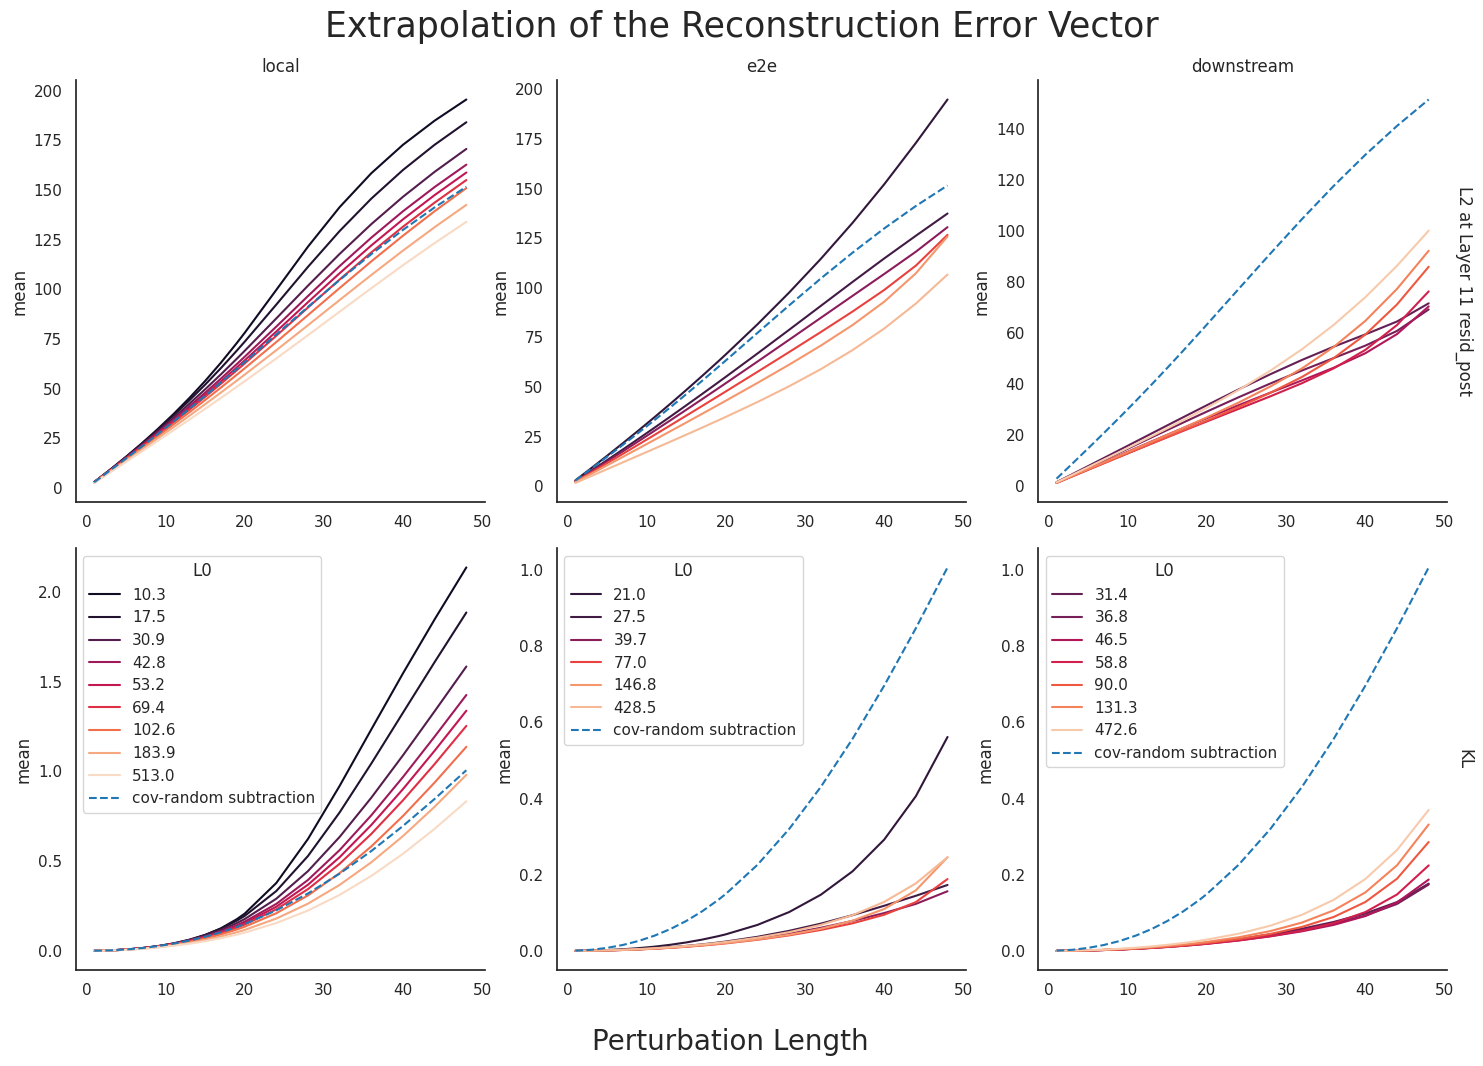

In [88]:
# sns.set_theme(style="darkgrid")

mean_df_melt_plot = mean_df_melt[mean_df_melt["perturbation_length"] < 50]
# mean_df_melt_plot = mean_df_melt[(mean_df_melt["L0"] >= 30)]

g = sns.FacetGrid(mean_df_melt_plot, col="run_type", row = "metric", height=5, margin_titles=True, hue = "L0", 
                  palette = 'rocket',  sharex=False, sharey=False)

g.map(sns.lineplot, "perturbation_length", "value")

g.set_titles(col_template="{col_name}", row_template="{row_name}")

g.fig.suptitle(f'Extrapolation of the Reconstruction Error Vector', y = 1.03, fontsize = 25)

g.set(xlabel= None, ylabel = "mean")

g.fig.text(0.4, -0.01, "Perturbation Length", fontsize = 20)

axes = g.fig.axes
i = 0
mean_df_all_baseline_melt_l2_limit = mean_df_all_baseline_melt_l2[mean_df_all_baseline_melt_l2["perturbation_length"] < 50]
mean_df_all_baseline_melt_kl_limit = mean_df_all_baseline_melt_kl[mean_df_all_baseline_melt_kl["perturbation_length"] < 50]


for ax in axes:
    if i < 3:
        ax.plot(mean_df_all_baseline_melt_l2_limit[mean_df_all_baseline_melt_l2_limit["baseline"] == "cov_random_mixture"]["perturbation_length"],
            mean_df_all_baseline_melt_l2_limit[mean_df_all_baseline_melt_l2_limit["baseline"] == "cov_random_mixture"]["value"],
            c='tab:blue', label = "cov-random subtraction", linestyle='dashed')
    else:
        ax.plot(mean_df_all_baseline_melt_kl_limit[mean_df_all_baseline_melt_kl_limit["baseline"] == "cov_random_mixture"]["perturbation_length"],
            mean_df_all_baseline_melt_kl_limit[mean_df_all_baseline_melt_kl_limit["baseline"] == "cov_random_mixture"]["value"],
            c='tab:blue', label = "cov-random subtraction", linestyle='dashed')

        ax.legend(title = "L0")
    i += 1


plt.savefig(f"{cwd}/results/figures/error_extrapolation_short.png", dpi = 500, bbox_inches = "tight")


In [54]:
mean_df_all

,index,position,loss,length_1_loss,length_1_kl,length_1_blocks.11.hook_resid_post_L2,length_3_loss,length_3_kl,length_3_blocks.11.hook_resid_post_L2,length_5_loss,...,length_91_kl,length_91_blocks.11.hook_resid_post_L2,sae_l0,sae_l1,reconstruction_error,norm,sae_norm,cos,run_type,L0
0,0,63.0,3.557865,3.555771,0.000234,3.009864,3.552943,0.002226,9.214687,3.552258,...,5.143910,274.873174,9.940678,93.285198,36.059806,102.278208,82.296992,0.900423,local,10.271713
1,0,63.0,3.557865,3.555722,0.000263,3.021967,3.552964,0.002472,9.216640,3.552547,...,4.705537,268.088051,16.954113,110.142098,29.591295,102.278208,88.185066,0.932581,local,17.468240
2,0,63.0,3.557865,3.555970,0.000275,3.004001,3.553799,0.002563,9.116976,3.554038,...,4.224886,257.158586,29.680497,127.461203,24.628616,102.278208,92.561010,0.952543,local,30.945175
3,0,63.0,3.557865,3.556109,0.000274,2.968408,3.554203,0.002535,8.983024,3.554645,...,3.902656,249.273315,40.660933,138.028827,22.497630,102.278208,94.373836,0.960076,local,42.798630
4,0,63.0,3.557865,3.555939,0.000271,2.935700,3.553676,0.002499,8.869851,3.553716,...,3.778744,246.877528,50.513713,145.083386,21.354410,102.278208,95.215543,0.964020,local,53.223964
5,0,63.0,3.557865,3.555952,0.000266,2.904089,3.553701,0.002450,8.761653,3.553709,...,3.584166,241.472960,66.485167,154.668322,20.072467,102.278208,96.156254,0.968153,local,69.426438
6,0,63.0,3.557865,3.555845,0.000257,2.842317,3.553301,0.002355,8.558730,3.552886,...,3.388152,237.659838,96.483264,169.283954,18.611699,102.278208,97.123783,0.972743,local,102.580427
7,0,63.0,3.557865,3.556474,0.000236,2.746343,3.555069,0.002150,8.254172,3.555595,...,3.072565,228.647661,175.879770,197.522936,16.504589,102.278208,98.395249,0.978490,local,183.948012
8,0,63.0,3.557865,3.556491,0.000215,2.625651,3.555000,0.001949,7.877234,3.555254,...,2.683502,215.186182,510.259476,277.317539,13.234724,102.278208,99.820891,0.986301,local,512.987541
9,0,63.0,3.557865,3.557959,0.000076,3.016883,3.558607,0.000709,9.139879,3.559924,...,10.899320,414.794812,23.053424,18.750163,96.847392,102.278219,10.764573,0.463443,e2e,21.028400


<Axes: xlabel='reconstruction_error', ylabel='substitution_kl'>

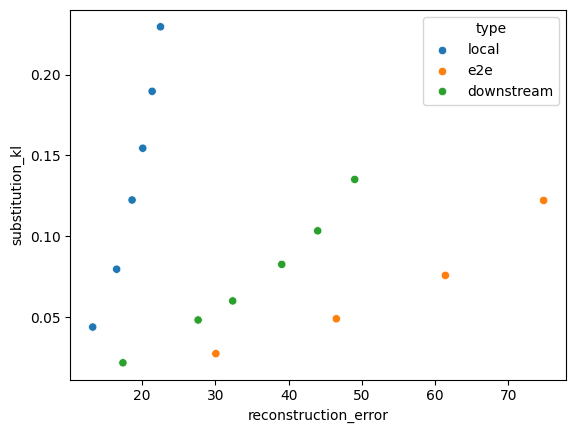

In [161]:
sns.scatterplot(data=mean_df_all, x="reconstruction_error", y="substitution_kl", hue="type")
